In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("car_details.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.shape

(4340, 8)

In [4]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
for col in df.columns:
    print("Unique values of " + col)
    print(df[col].unique())
    print("=========================")

Unique values of name
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']
Unique values of year
[2007 2012 2017 2014 2016 2015 2018 2019 2013 2011 2010 2009 2006 1996
 2005 2008 2004 1998 2003 2002 2020 2000 1999 2001 1995 1997 1992]
Unique values of selling_price
[  60000  135000  600000  250000  450000  140000  550000  240000  850000
  365000  260000 1650000  585000 1195000  390000 1964999 1425000  975000
 1190000  930000  525000 1735000 1375000  900000 1300000 1400000  229999
 1550000 1250000  625000 1050000  560000  290000  275000  411000  150000
  500000  100000  725000  401000  750000  310000  665000  465000  160000
  675000  300000   70000  151000  280000  350000  570000  125000  130000
  925000  200000  248000   80000  650000  495000  371000 1025000 8150000
  325000 1470000 2800000  210000 1150000 4500000 2750000 1975000  175000
 2500000  628000  399

In [7]:
def get_brand_name(name):
    car_name = name.split(' ')[0]
    return car_name.strip(' ')

In [8]:
get_brand_name('Maruti 800 AC')

'Maruti'

In [9]:
df['name'] = df['name'].apply(get_brand_name)

In [10]:
df['name'].unique()

array(['Maruti', 'Hyundai', 'Datsun', 'Honda', 'Tata', 'Chevrolet',
       'Toyota', 'Jaguar', 'Mercedes-Benz', 'Audi', 'Skoda', 'Jeep',
       'BMW', 'Mahindra', 'Ford', 'Nissan', 'Renault', 'Fiat',
       'Volkswagen', 'Volvo', 'Mitsubishi', 'Land', 'Daewoo', 'MG',
       'Force', 'Isuzu', 'OpelCorsa', 'Ambassador', 'Kia'], dtype=object)

In [11]:
def brand_category(name):
    luxury = ['BMW', 'Audi', 'Mercedes-Benz', 'Jaguar', 'Volvo']
    mid = ['Toyota', 'Honda', 'Hyundai', 'Volkswagen', 'Skoda']
    
    if name in luxury:
        return 'Luxury'
    elif name in mid:
        return 'Mid'
    else:
        return 'Budget'

df['brand'] = df['name'].apply(brand_category)

In [12]:
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

In [13]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand_Luxury,brand_Mid
0,Maruti,2007,60000,70000,Petrol,Individual,Manual,First Owner,False,False
1,Maruti,2007,135000,50000,Petrol,Individual,Manual,First Owner,False,False
2,Hyundai,2012,600000,100000,Diesel,Individual,Manual,First Owner,False,True
3,Datsun,2017,250000,46000,Petrol,Individual,Manual,First Owner,False,False
4,Honda,2014,450000,141000,Diesel,Individual,Manual,Second Owner,False,True


In [14]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand_Luxury,brand_Mid
4335,Hyundai,2014,409999,80000,Diesel,Individual,Manual,Second Owner,False,True
4336,Hyundai,2014,409999,80000,Diesel,Individual,Manual,Second Owner,False,True
4337,Maruti,2009,110000,83000,Petrol,Individual,Manual,Second Owner,False,False
4338,Hyundai,2016,865000,90000,Diesel,Individual,Manual,First Owner,False,True
4339,Renault,2016,225000,40000,Petrol,Individual,Manual,First Owner,False,False


In [15]:
df['fuel'].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [16]:
df['fuel'] = df['fuel'].replace(['CNG', 'LPG', 'Electric'], 'Other')

In [17]:
df['seller_type'].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

In [18]:
df['transmission'].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [19]:
df['owner'].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

In [20]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

In [21]:
df['owner'] = df['owner'].str.strip()

In [22]:
owner_map = {
    "Test Drive Car": 0,
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4
}

df['owner'] = df['owner'].map(owner_map)

In [23]:
df['owner'].value_counts()

owner
1    2832
2    1106
3     304
4      81
0      17
Name: count, dtype: int64

In [24]:
df['owner'].isnull().sum()

np.int64(0)

In [25]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand_Luxury,brand_Mid
0,Maruti,2007,60000,70000,Petrol,Individual,Manual,1,False,False
1,Maruti,2007,135000,50000,Petrol,Individual,Manual,1,False,False
2,Hyundai,2012,600000,100000,Diesel,Individual,Manual,1,False,True
3,Datsun,2017,250000,46000,Petrol,Individual,Manual,1,False,False
4,Honda,2014,450000,141000,Diesel,Individual,Manual,2,False,True


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   int64 
 8   brand_Luxury   4340 non-null   bool  
 9   brand_Mid      4340 non-null   bool  
dtypes: bool(2), int64(4), object(4)
memory usage: 279.9+ KB


In [27]:
df.drop('name', axis=1, inplace=True)

In [28]:
df = pd.get_dummies(df, drop_first=True)

In [29]:
df.head()

,year,selling_price,km_driven,owner,brand_Luxury,brand_Mid,fuel_Other,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,2007,60000,70000,1,False,False,False,True,True,False,True
1,2007,135000,50000,1,False,False,False,True,True,False,True
2,2012,600000,100000,1,False,True,False,False,True,False,True
3,2017,250000,46000,1,False,False,False,True,True,False,True
4,2014,450000,141000,2,False,True,False,False,True,False,True


In [30]:
df['car_age'] = 2026 - df['year']
df.drop('year', axis=1, inplace=True)

In [31]:
df.head()

,selling_price,km_driven,owner,brand_Luxury,brand_Mid,fuel_Other,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,car_age
0,60000,70000,1,False,False,False,True,True,False,True,19
1,135000,50000,1,False,False,False,True,True,False,True,19
2,600000,100000,1,False,True,False,False,True,False,True,14
3,250000,46000,1,False,False,False,True,True,False,True,9
4,450000,141000,2,False,True,False,False,True,False,True,12


In [32]:
X = df.drop("selling_price",axis=1)
y = df["selling_price"]

In [33]:
print(X.shape)
print(y.shape)

(4340, 10)
(4340,)


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [35]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(3472, 10) (868, 10)
(3472,) (868,)


In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
print("R2:", r2_score(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

R2: 0.48029902788901735
MAE: 207896.6500695871
RMSE: 398242.7580478138


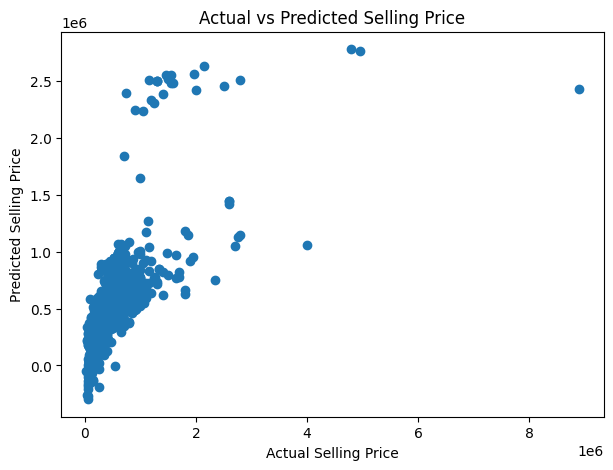

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

In [40]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

In [41]:
print(coeff_df.head(10))

                        Feature   Coefficient
2                  brand_Luxury  1.614284e+06
7  seller_type_Trustmark Dealer  2.973831e+05
3                     brand_Mid  8.785297e+04
0                     km_driven -7.475124e-01
1                         owner -9.257328e+03
6        seller_type_Individual -2.178981e+04
9                       car_age -4.063902e+04
4                    fuel_Other -2.235278e+05
5                   fuel_Petrol -2.291838e+05
8           transmission_Manual -3.723892e+05


In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R2: 0.6947633395985248
Random Forest MAE: 143289.12593036008
Random Forest RMSE: 305203.47143866523


In [44]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.head(10)

,Feature,Importance
2,brand_Luxury,0.426305
9,car_age,0.282642
0,km_driven,0.140004
5,fuel_Petrol,0.048000
8,transmission_Manual,0.042997
6,seller_type_Individual,0.024944
3,brand_Mid,0.013642
1,owner,0.011970
7,seller_type_Trustmark Dealer,0.007642
4,fuel_Other,0.001854


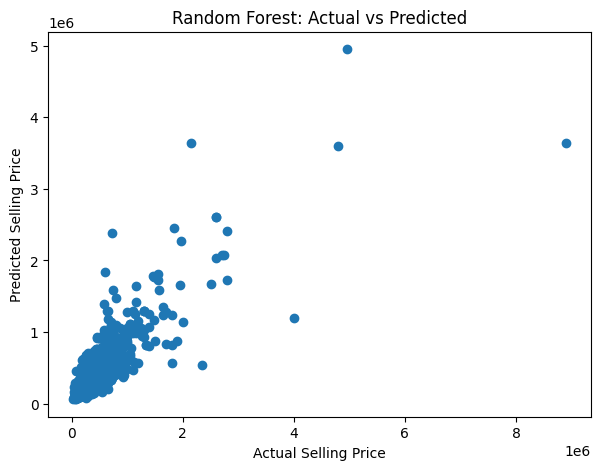

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()